In [1]:
import pandas as pd
from openpyxl import load_workbook
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc
rc("font", **{"family": "serif", "serif": ["Computer Modern"], "size":18})
rc("text", usetex=True)


In [2]:
from nuclearpy_models.models.rc import sr_rc, mnp_rc

['../../Data/Theory/FRDM2012.csv']


In [3]:
exp_df = pd.read_csv('../../Data/Experimental/rc.csv', delimiter=',').query("Z>12").drop_duplicates(subset=['Z', 'N']).query("Z<=50")
exp_df["A"] = exp_df["Z"] + exp_df["N"]

In [4]:
PATH_THEORY = "../../Data/Theory/MasterNuclei.xlsx"
def get_sheets_name(filename):
    workbook = load_workbook(filename)
    return workbook.sheetnames

used_dfs = [
    # "DD-ME2",
    "SKMS",
    "NL3S",
    "UNEDF1",
]

th_datastes = get_sheets_name(PATH_THEORY)
th_datastes = [th_dataste for th_dataste in th_datastes if th_dataste in used_dfs]
# th_datastes = [th_dataste for th_dataste in used_dfs if th_dataste != "AME2020"]
thdfs = {th_dataste: pd.read_excel(PATH_THEORY, sheet_name=th_dataste).query("Z >= 12 and N>=12").query("(N+Z)<250") for th_dataste in th_datastes}
th_w_target_df = {th_dataste: thdfs[th_dataste].rename(columns={"ChRad": "Rav"} ) for th_dataste in th_datastes if "ChRad" in thdfs[th_dataste].columns and "AME2020" not in th_dataste}

In [5]:
th_w_target_df = {th_dataste: thdfs[th_dataste].rename(columns={"ChRad": "Rav"} ) for th_dataste in th_datastes}

In [7]:
train_df = pd.read_csv('../../Data/Experimental/rc_train.csv', delimiter=',').query("Z>=12").drop_duplicates(subset=['Z', 'N'])
test_df = pd.read_csv('../../Data/Experimental/rc_test.csv', delimiter=',').query("Z>=12").drop_duplicates(subset=['Z', 'N'])
exp_df["is_train"] = [np.nan]*len(exp_df)
for Z, N in zip(test_df["Z"], test_df["N"]):
    try:
        exp_df["is_train"][(exp_df["Z"]==Z) & (exp_df["N"]==N)] = False
    except:
        print(Z, N)
for Z, N in zip(train_df["Z"], train_df["N"]):
    try:
        exp_df["is_train"][(exp_df["Z"]==Z) & (exp_df["N"]==N)] = True
    except:
        print(Z, N)

/var/folders/zg/s97g7gnj27z83xl9nrhntgxm0000gn/T/ipykernel_80214/373354907.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exp_df["is_train"][(exp_df["Z"]==Z) & (exp_df["N"]==N)] = False


In [8]:
exp_df.Z.min()

13

In [11]:
for key, th_dset in th_w_target_df.items():
    exp_df[key] = [np.nan] * len(exp_df)


In [12]:
%%capture
for key, th_dset in th_w_target_df.items():
    missing = 0
    for Z, N in zip(th_dset["Z"], th_dset["N"]):
        try:
            exp_df[key].loc[(exp_df["Z"]==Z) & (exp_df["N"]==N)] = th_dset["Rav"].loc[(th_dset["Z"]==Z) & (th_dset["N"]==N)].values[0]
        except:
            missing+=1
    print(f"{key} missing {missing} values")

In [13]:
def plot_range_no_ref(Z, n_min, n_max, sq = True, index=-1,
                      save_path=None, add_label="",
                      avoid_th=False,
                      ):
    fig, ax = plt.subplots(figsize=(10, 8))
    n = np.arange(n_min, n_max+1)
    if not sq:
        plt.errorbar(exp_df.query(f"Z=={Z}")["N"], exp_df.query(f"Z=={Z}")["Rav"], yerr=exp_df.query(f"Z=={Z}")["delta_Rav"], fmt='o', label="Experiment",                   color="black")
        sns.lineplot(x=exp_df.query(f"Z=={Z}")["N"], y=exp_df.query(f"Z=={Z}")["Rav"], color="black")
        if not avoid_th:
            for key, th_dset in th_w_target_df.items():
                foo_df = exp_df.query(f"Z=={Z}").query(f"N>={n_min} and N<={n_max}")[["Z",
                    "N", key]].dropna()
                # plt.scatter(foo_df["N"], foo_df[key], label=key, s=10)
                # plt.plot(foo_df["N"], foo_df[key], ls="--", alpha=0.5)

        preds_sr = [sr_rc(Z, n, index=index) for n in n]
        unc = [pred[1] for pred in preds_sr]
        preds_sr = [pred[0] for pred in preds_sr]
        preds_mnp = [mnp_rc(Z, n) for n in n]
        plt.plot(n, preds_mnp, color="grey", alpha=0.5)
        plt.scatter(n, preds_mnp,  label="Nerlo-Pomorska",color="grey", s=10)
        plt.plot(n, preds_sr, color="blue")
        plt.scatter(n, preds_sr, color="blue", label=r"$r_{c\ MISR}$")
        # plt.fill_between(n, np.array(preds_sr)-np.array(unc), np.array(preds_sr)+np.array(unc), color="blue", alpha=0.1)
        plt.xlabel("N")
        plt.ylabel(r"$r_c$ [fm]")
        plt.legend(loc="best", ncols=2)
    else:
        n = np.arange(n_min, n_max+1)
        sns.lineplot(x=exp_df.query(f"Z=={Z}")["N"], y=exp_df.query(f"Z=={Z}")["Rav"]**2, color="black")
        delta_r_unc = exp_df.query(f"Z=={Z}")["delta_Rav"]**2 + 2*exp_df.query(f"Z=={Z}")["Rav"]*exp_df.query(f"Z=={Z}")["delta_Rav"]
        plt.errorbar(exp_df.query(f"Z=={Z}")["N"], exp_df.query(f"Z=={Z}")["Rav"]**2, yerr=delta_r_unc, fmt='s', label="Experiment", color="black")
        # if not avoid_th:
        #     for key, th_dset in th_w_target_df.items():
        #         foo_df = exp_df.query(f"Z=={Z}").query(f"N>={n_min} and N<={n_max}")[["Z",
        #             "N", key]].dropna()
        #         deltas = (foo_df[key]**2)
        #         plt.scatter(foo_df["N"], deltas, label=key, s=10)
        #         plt.plot(foo_df["N"],deltas, ls="--", alpha=0.6)
        preds_mnp = [mnp_rc(Z, n)**2 for n in n]
        deltas_mnp = (np.array(preds_mnp))
        plt.plot(n, deltas_mnp, color="grey", alpha=0.6, ls="--")
        plt.scatter(n, deltas_mnp,  label="NP",color="grey", s=10)
        preds_sr = [sr_rc(Z, n, index=index) for n in n]
        unc = [pred[1] for pred in preds_sr]
        preds_sr = [pred[0]**2 for pred in preds_sr]
        deltas_sr = (np.array(preds_sr) )
        unc_delta_sr = (np.array(unc)**2 + 2*np.array(preds_sr)*np.array(unc))
        plt.plot(n, deltas_sr, color="blue")
        plt.scatter(n, deltas_sr, color="blue", label=r"$r_{c\ MISR}$")
        # plt.fill_between(n, deltas_sr-unc_delta_sr, deltas_sr+unc_delta_sr, color="blue", alpha=0.1)
        plt.xlabel("N")
        plt.ylabel(r"$\langle r_c^2\rangle$ [fm$^2$]")
        plt.legend(loc="upper left", ncols=2)
    if add_label:
        fig.add_artist(plt.Text(0.5, 0.2, add_label, fontsize=25))
    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')


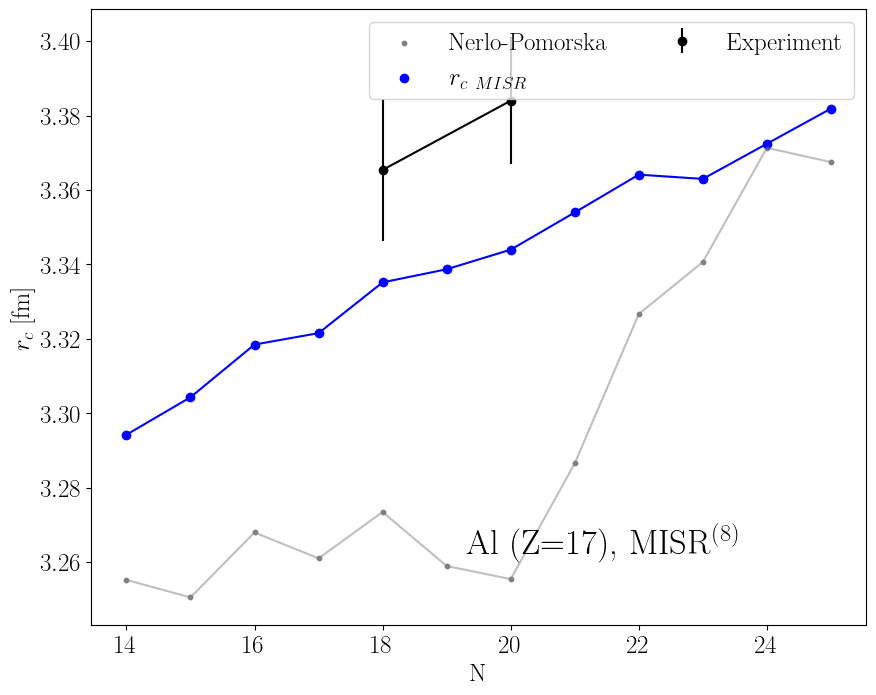

In [21]:
plot_range_no_ref(Z=17, n_min=14, n_max=25, sq=False, index=4, add_label="Al (Z=$17$), MISR$^{(8)}$")

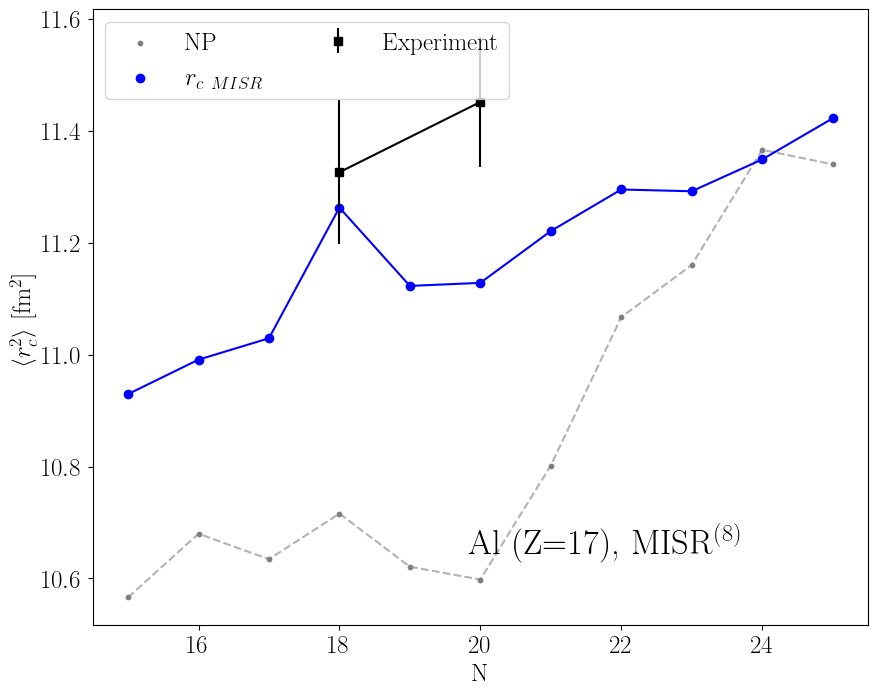

In [16]:
plot_range_no_ref(Z=17, n_min=15, n_max=25, sq=True, index=-1, add_label="Al (Z=$17$), MISR$^{(8)}$")

In [17]:
Z = 17
n = np.arange(15, 26)
A = np.array([Z + n_i for n_i in n])
preds_sr = [sr_rc(Z, n_i, index=8) for n_i in n]
RESU_DF = pd.DataFrame(
    {"A": A, "N": n, "Z": [Z]*len(n), "<r> [fm]": [pred[0] for pred in preds_sr], r"unc. <r> [fm]": [pred[1] for pred in preds_sr]}
)
RESU_DF

,A,N,Z,<r> [fm],unc. <r> [fm]
0,32,15,17,3.302876,0.019602
1,33,16,17,3.317372,0.010173
2,34,17,17,3.321150,0.010118
3,35,18,17,3.357706,0.031369
4,36,19,17,3.336632,0.006341
5,37,20,17,3.336075,0.035137
6,38,21,17,3.351530,0.006239
7,39,22,17,3.362085,0.005710
8,40,23,17,3.360914,0.011093
9,41,24,17,3.370340,0.007806
